In [2]:
import xradar as xd
import sys
import wradlib as wrl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import cmap
from scipy.ndimage import (
    median_filter,
    gaussian_filter,
    generic_filter,
    uniform_filter,
    label,
)

In [3]:
# PLOTERS
###############################################################################

def plot_features(ax):
    states = cfeature.STATES.with_scale('10m')
    ax.add_feature(states, edgecolor="black", lw=2, zorder=4)

In [4]:
# HELPERS
###############################################################################

def texture_std(x):

    #valid = np.isfinite(x)

    #if np.sum(valid) < 1000:
    #    return np.nan

    return np.nanstd(x)

def compute_texture(field, size=(1, 5)):
    """
    Compute local texture of a radar field.
    """

    arr = field.values.copy()

    tex = generic_filter(
        arr,
        texture_std,
        size=size,
        mode="nearest"
    )

    return xr.DataArray(
        tex,
        dims=field.dims,
        coords=field.coords
    )

In [29]:
filepath = "data/raw/santa_elena/2026/02/01/9100SAN-20260201-094032-PPIVol-0478.nc"
dt = xd.io.open_cfradial1_datatree(filepath, decode_times=False)

swp = dt["/sweep_0"]
print(swp)

<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:                          (sweep: 1, frequency: 1, azimuth: 1333,
                                          range: 960)
    Coordinates:
      * azimuth                          (azimuth) float32 5kB 0.0769 ... 359.8
        time                             (azimuth) float64 11kB 14.0 14.0 ... 13.0
        elevation                        (azimuth) float32 5kB ...
      * range                            (range) float32 4kB 62.5 ... 1.199e+05
        latitude                         float64 8B ...
        longitude                        float64 8B ...
        altitude                         float64 8B ...
    Inherited coordinates:
      * frequency                        (frequency) float32 4B 5.6e+09
    Dimensions without coordinates: sweep
    Data variables: (12/30)
        radar_measured_transmit_power_h  (azimuth) float32 5kB ...
        radar_measured_transmit_power_v  (azimuth) float32 5kB ...
        pulse_width    

In [113]:
alpha=0.01
rhohv_thresh=0.85
snr_thresh=8
ncp_thresh=0.3
texture_thresh=3

In [114]:
###########################################################################
# VARIABLES
###########################################################################
DBZH = swp["DBZH"]
PHIDP = swp["PHIDP"]
KDP = swp["KDP"]
RHOHV = swp["RHOHV"]
NCP = xr.ufuncs.minimum(
    swp["NCPH"],
    swp["NCPV"]
)
SNR = xr.ufuncs.minimum(
    swp["SNRHC"],
    swp["SNRVC"]
)


In [115]:
###########################################################################
# 1. METEOROLOGICAL MASK
###########################################################################

met_mask = (
      (RHOHV > rhohv_thresh)
    & (SNR > snr_thresh)
    #& (NCP > ncp_thresh) 
    & (DBZH > 0)
)

In [116]:
###########################################################################
# 2. REMOVE ISOLATED PIXELS
###########################################################################

#density = uniform_filter(
#    met_mask.astype(float),
#    size=(3,5)
#)

#met_mask = density > 0.5

mask_vals = met_mask.values.copy()

labels, num = label(mask_vals)

sizes = np.bincount(labels.ravel())

min_size = 3

small = sizes < min_size

# Preserve background
small[0] = False

remove_mask = small[labels]

mask_vals[remove_mask] = False

met_mask = xr.DataArray(
    mask_vals,
    dims=met_mask.dims,
    coords=met_mask.coords
)

In [117]:
###########################################################################
# 3. FILTER REFLECTIVITY
###########################################################################

cDBZH = xr.where(
    met_mask,
    DBZH,
    np.nan
)

In [118]:
###########################################################################
# 4. INITIAL PHIDP SMOOTHING
###########################################################################

phi_vals = PHIDP.values.copy()

phi_vals = np.nan_to_num(
    phi_vals,
    nan=0
)

phi_med = median_filter(
    phi_vals,
    size=(1,8)
)

sPHIDP = xr.DataArray(
    phi_med,
    dims=PHIDP.dims,
    coords=PHIDP.coords
)

In [119]:
###########################################################################
# 5. PHIDP TEXTURE
###########################################################################

tPHIDP = compute_texture(
    sPHIDP,
    size=(1,5)
)

In [120]:
###########################################################################
# 6. PHIDP QUALITY MASK
###########################################################################

phi_mask = (
       met_mask
    #& (tPHIDP < texture_thresh)
)

In [121]:
###########################################################################
# 7. FILTERED PHIDP
###########################################################################

fPHIDP = xr.where(
    phi_mask,
    sPHIDP,
    np.nan
)

In [122]:
###########################################################################
# 8. FINAL PHIDP SMOOTHING
###########################################################################

vals = np.nan_to_num(
    fPHIDP.values,
    nan=0
)

vals = median_filter(
    vals,
    size=(1,5)
)

vals = gaussian_filter(
    vals,
    sigma=(0,1)
)

vals[~phi_mask.values] = np.nan

In [123]:
###########################################################################
# 9. MONOTONIC ENFORCEMENT
###########################################################################

#vals = np.maximum.accumulate(
#    vals,
#    axis=1
#)

fPHIDP = xr.DataArray(
    vals,
    dims=PHIDP.dims,
    coords=PHIDP.coords
)

In [124]:
###########################################################################
# 10. CLEAN KDP
###########################################################################

cKDP = xr.where(
    phi_mask,
    KDP,
    np.nan
)

In [125]:
###########################################################################
# 11. SPECIFIC ATTENUATION
###########################################################################

A = alpha * cKDP

###########################################################################
# 12. RANGE RESOLUTION
###########################################################################

dr = float(
    swp["range"][1] - swp["range"][0]
)

dr_km = dr / 1000.0

###########################################################################
# 13. PIA
###########################################################################

pia_vals = 2 * np.nancumsum(
    A.values * dr_km,
    axis=1
)

PIA = xr.DataArray(
    pia_vals,
    dims=A.dims,
    coords=A.coords
)

###########################################################################
# 14. ATTENUATION CORRECTED REFLECTIVITY
###########################################################################

cDBZH_attcorr = cDBZH + PIA

###########################################################################
# 15. RAINFALL ESTIMATION
###########################################################################

# R(A)
R_A = 4120 * (A ** 1.03)

# R(KDP)
R_KDP = 40.6 * (cKDP ** 0.85)

In [126]:
swp["met_mask"] = met_mask

swp["sPHIDP"] = sPHIDP

swp["tPHIDP"] = tPHIDP

swp["fPHIDP"] = fPHIDP

swp["cKDP"] = cKDP

swp["A"] = A

swp["PIA"] = PIA

swp["cDBZH"] = cDBZH_attcorr

swp["R_A"] = R_A

swp["R_KDP"] = R_KDP

In [127]:
var = "DBZH"

<xarray.DataArray 'DBZH' (azimuth: 1333, range: 960)> Size: 5MB
array([[-19.5, -19.5,   nan, ...,   nan,   nan,   nan],
       [-20. , -20. ,   nan, ...,   nan,   nan,   nan],
       [-20. , -20. ,   nan, ...,   nan,   nan,   nan],
       ...,
       [-20. , -20. ,   nan, ...,   nan,   nan,   nan],
       [-20. , -20. ,   nan, ...,   nan,   nan,   nan],
       [-20.5, -20.5,   nan, ...,   nan,   nan,   nan]],
      shape=(1333, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 5kB 0.0769 0.3488 0.6152 ... 359.3 359.5 359.8
    time       (azimuth) float64 11kB 14.0 14.0 14.0 14.0 ... 13.0 13.0 13.0
    elevation  (azimuth) float32 5kB 3.999 3.999 3.999 ... 3.999 3.999 3.999
  * range      (range) float32 4kB 62.5 187.5 312.5 ... 1.198e+05 1.199e+05
    latitude   float64 8B 6.191
    longitude  float64 8B -75.53
    altitude   float64 8B 2.813e+03
Attributes:
    long_name:   equivalent_reflectivity_factor_h
    units:       dBZ
    sweep_mode:  ppi


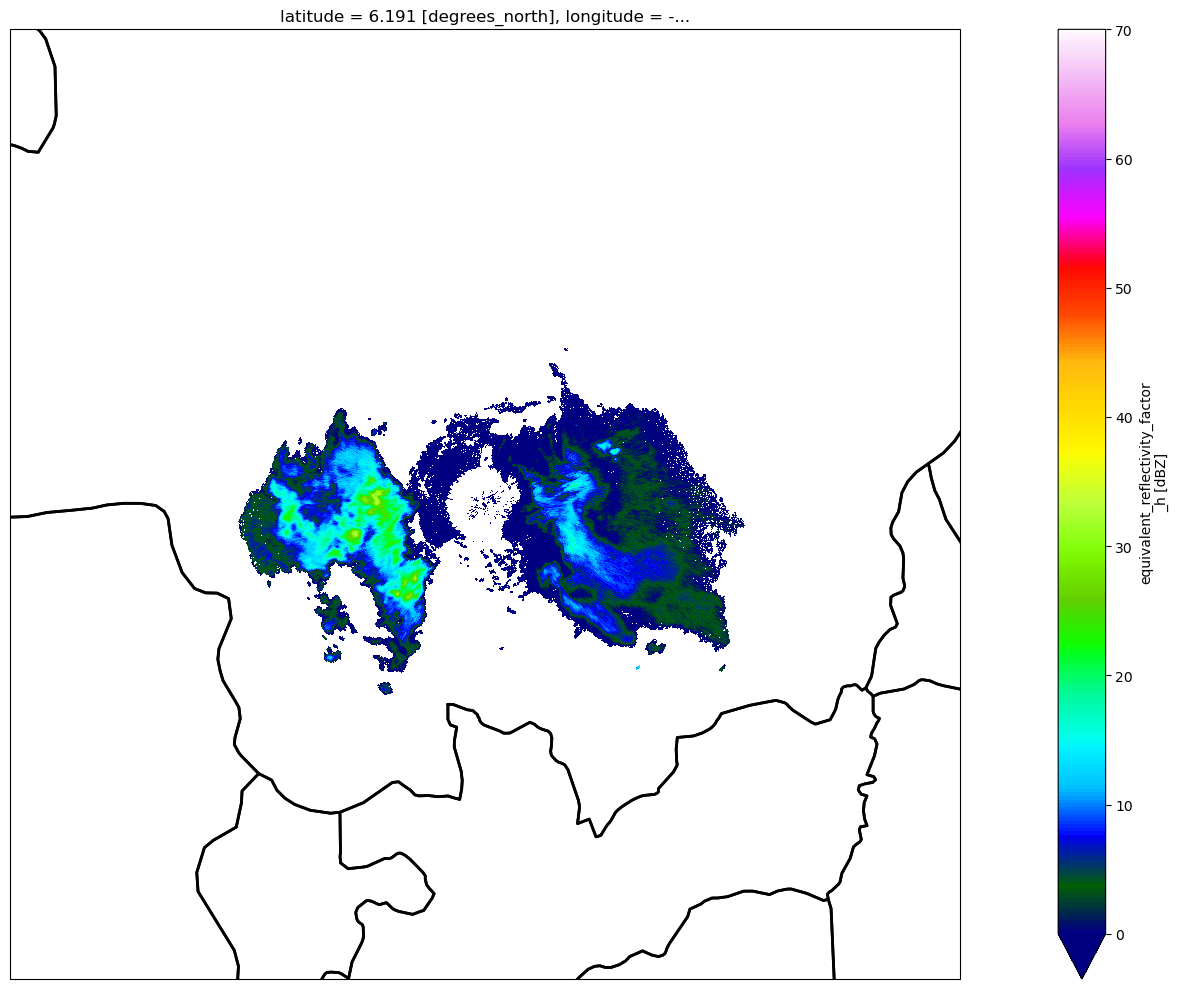

In [128]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=70,
    cmap=cmap.Colormap("ncar").to_mpl(),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [129]:
var = "cDBZH"

<xarray.DataArray 'cDBZH' (azimuth: 1333, range: 960)> Size: 5MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1333, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 5kB 0.0769 0.3488 0.6152 ... 359.3 359.5 359.8
    time       (azimuth) float64 11kB 14.0 14.0 14.0 14.0 ... 13.0 13.0 13.0
    elevation  (azimuth) float32 5kB 3.999 3.999 3.999 ... 3.999 3.999 3.999
  * range      (range) float32 4kB 62.5 187.5 312.5 ... 1.198e+05 1.199e+05
    latitude   float64 8B 6.191
    longitude  float64 8B -75.53
    altitude   float64 8B 2.813e+03
Attributes:
    long_name:   equivalent_reflectivity_factor_h
    units:       dBZ
    sweep_mode:  ppi


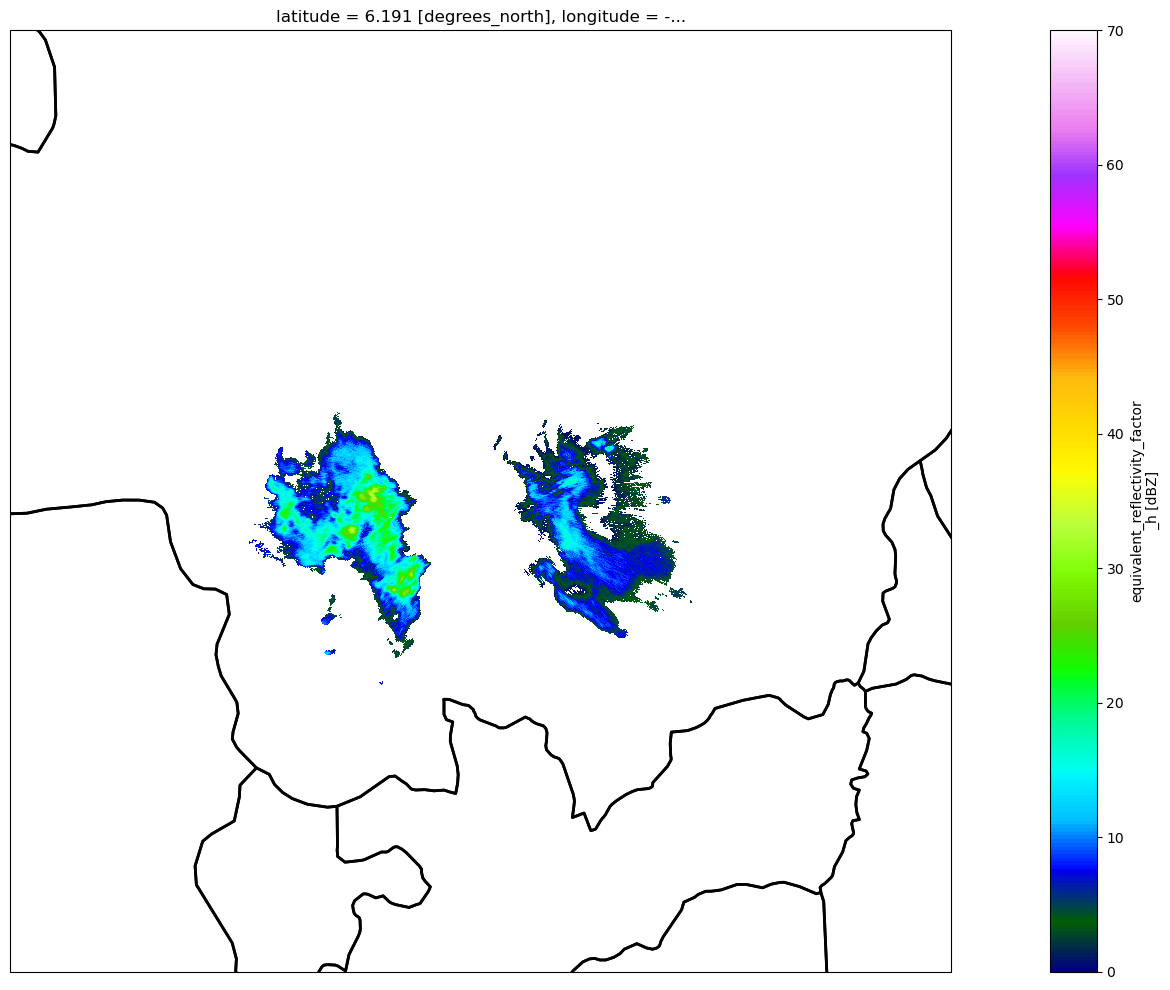

In [130]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=70,
    cmap=cmap.Colormap("ncar").to_mpl(),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [171]:
var = "cKDP"

<xarray.DataArray 'cKDP' (azimuth: 1333, range: 960)> Size: 5MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1333, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 5kB 0.0769 0.3488 0.6152 ... 359.3 359.5 359.8
    time       (azimuth) float64 11kB 14.0 14.0 14.0 14.0 ... 13.0 13.0 13.0
    elevation  (azimuth) float32 5kB 3.999 3.999 3.999 ... 3.999 3.999 3.999
  * range      (range) float32 4kB 62.5 187.5 312.5 ... 1.198e+05 1.199e+05
    latitude   float64 8B 6.191
    longitude  float64 8B -75.53
    altitude   float64 8B 2.813e+03
Attributes:
    long_name:   specific_differential_phase_hv
    units:       degrees/km
    sweep_mode:  ppi


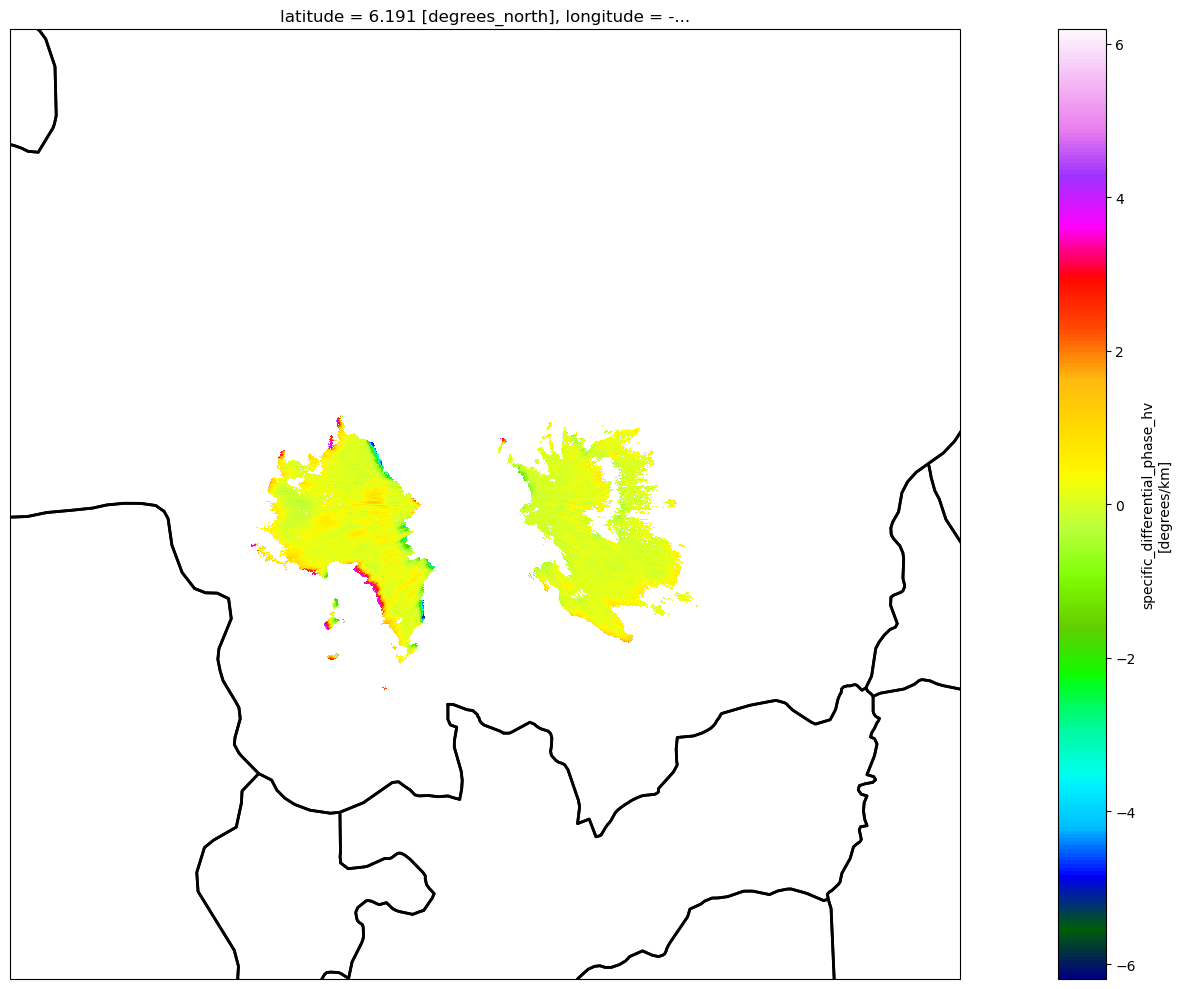

In [172]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [161]:
var = "fPHIDP"

<xarray.DataArray 'fPHIDP' (azimuth: 1333, range: 960)> Size: 5MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1333, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 5kB 0.0769 0.3488 0.6152 ... 359.3 359.5 359.8
    time       (azimuth) float64 11kB 14.0 14.0 14.0 14.0 ... 13.0 13.0 13.0
    elevation  (azimuth) float32 5kB 3.999 3.999 3.999 ... 3.999 3.999 3.999
  * range      (range) float32 4kB 62.5 187.5 312.5 ... 1.198e+05 1.199e+05
    latitude   float64 8B 6.191
    longitude  float64 8B -75.53
    altitude   float64 8B 2.813e+03


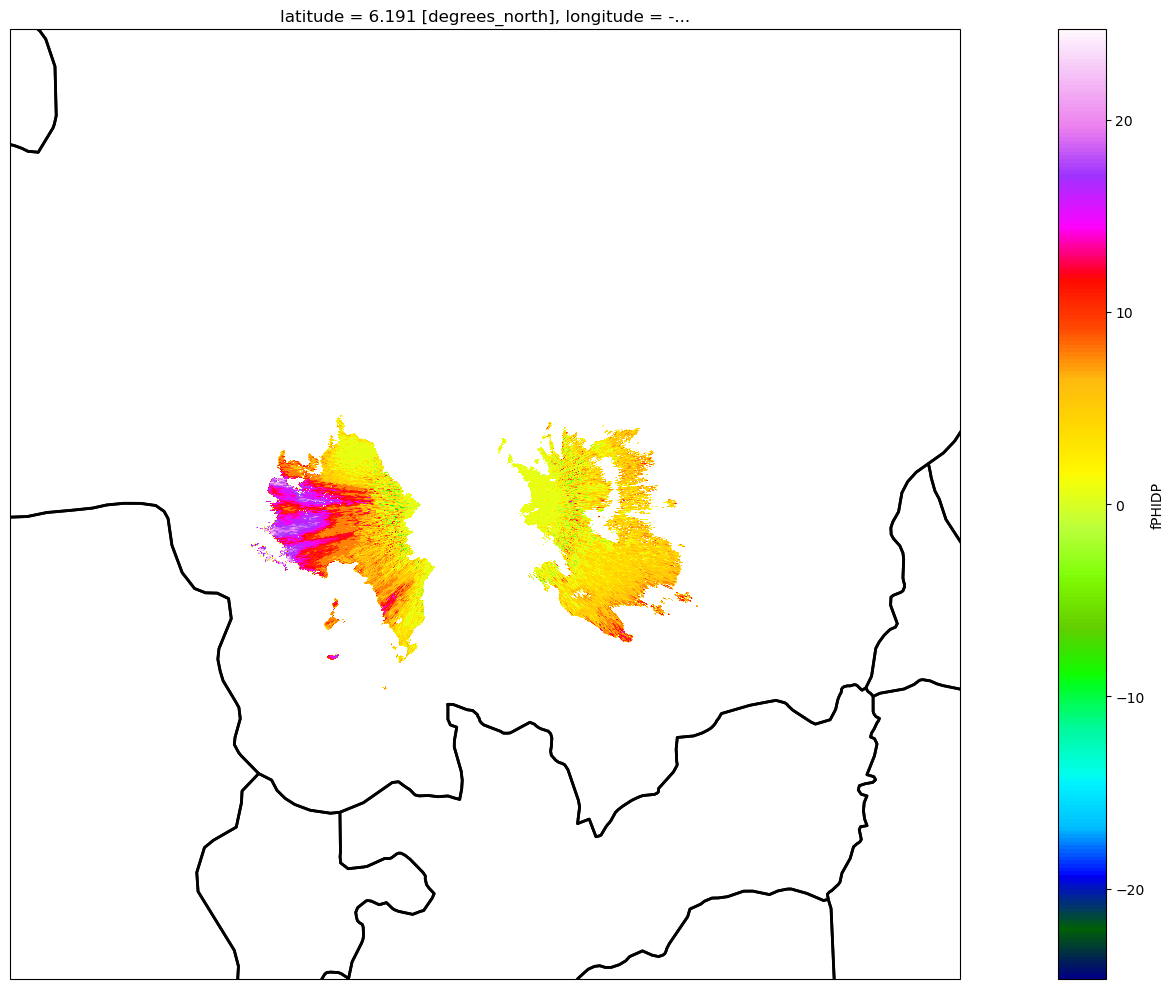

In [162]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [167]:
var = "R_A"

<xarray.DataArray 'R_A' (azimuth: 1333, range: 960)> Size: 5MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(1333, 960), dtype=float32)
Coordinates:
  * azimuth    (azimuth) float32 5kB 0.0769 0.3488 0.6152 ... 359.3 359.5 359.8
    time       (azimuth) float64 11kB 14.0 14.0 14.0 14.0 ... 13.0 13.0 13.0
    elevation  (azimuth) float32 5kB 3.999 3.999 3.999 ... 3.999 3.999 3.999
  * range      (range) float32 4kB 62.5 187.5 312.5 ... 1.198e+05 1.199e+05
    latitude   float64 8B 6.191
    longitude  float64 8B -75.53
    altitude   float64 8B 2.813e+03
Attributes:
    long_name:   specific_differential_phase_hv
    units:       degrees/km
    sweep_mode:  ppi


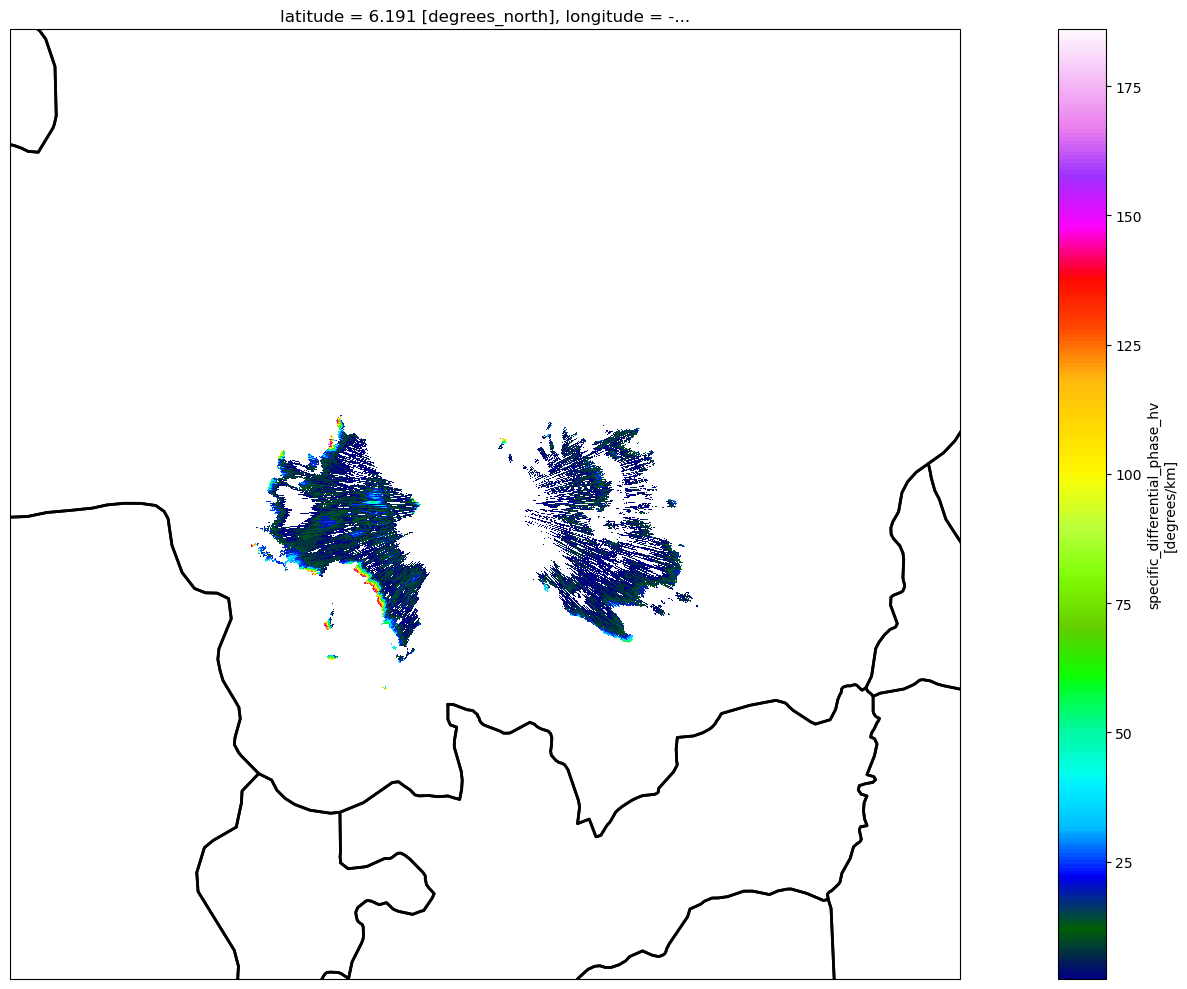

In [168]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()